In [1]:
import sys
import os
def get_FACEGroup_Directory():
    """Get the path of the 'FACEGroup-Feasible-and-Actionable-Counterfactual-Explanations-for-Group-Fairness-Auditing' directory."""
    current_dir = os.getcwd()
    target_dir = 'FACEGroup-Feasible-and-Actionable-Counterfactual-Explanations-for-Group-Fairness-Auditing'
    
    while os.path.basename(current_dir) != target_dir:
        current_dir = os.path.dirname(current_dir)
        if current_dir == os.path.dirname(current_dir):
            return None
        
    return current_dir

def get_system_slash():
    """Get the system-specific directory separator."""
    return os.sep

FACEGroup_DIR = get_FACEGroup_Directory()
sys.path.append(FACEGroup_DIR)
sep = get_system_slash()
sys.path.append(FACEGroup_DIR + get_system_slash() + 'src')
from main import *

from utils import *
from test_utils import *
from FACEGroup import *
from kernel import *
from dataLoader import *

2025-03-14 21:10:55.987277: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-14 21:10:55.987305: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-14 21:10:55.988321: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-14 21:10:55.993147: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-14 21:10:56.509651: W tensorflow/compiler/tf2

In [2]:
%load_ext autoreload
%autoreload 2

# Cost-Constrained Problem: Greedy - Mip Comparison

In [3]:
datasetName = "Adult"
epsilon = 0.4
k_range = list(nice_numbers(2, 20, 10, score='k'))
max_d = 1.05
results, mips_time, greedy_time, mips_total_coverage, greedy_total_coverage  = mip_to_greedy_comparison(datasetName=datasetName, epsilon=epsilon,
                                                          k_range=k_range, max_d=max_d,
                                                          representation=16, mip_runs=1)

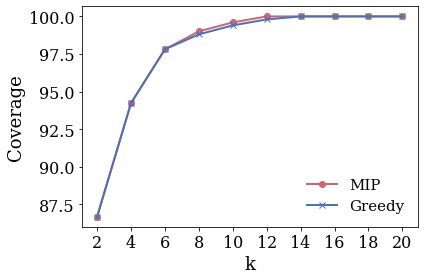

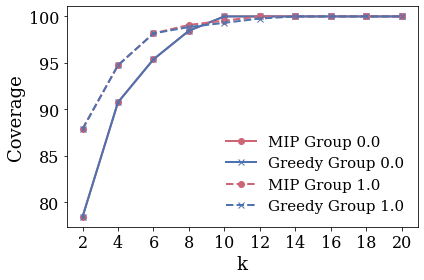

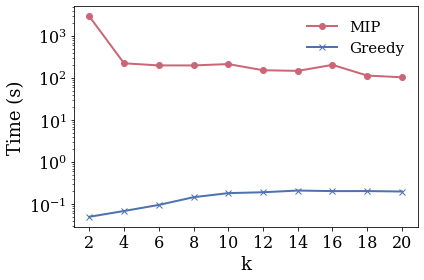

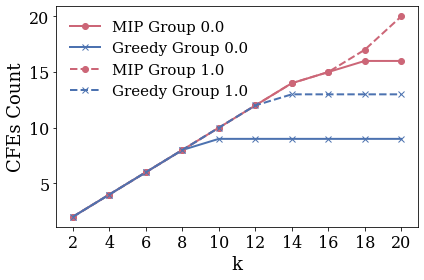

In [4]:
mip_vs_greedy_plot(datasetName, results, mips_time, greedy_time, mips_total_coverage, greedy_total_coverage, k_range=k_range, max_d=max_d)

# Coverage-Constrained Problem: Greedy - Mip Comparison

In [ ]:
datasetName = 'Adult'
epsilon = 0.4
group_identifier_value = None
skip_model_training = True
skip_distance_calculation = True
verbose = False
skip_graph_creation = True
representation = 64
skip_bandwith_calculation = True
classifier = 'xgb'
group_identifier="sex"
bandwith_approch = "mean_scotts_rule"
skip_fgce_calculation = True
cost_function = "max_vector_distance"
cov_constr_approach = "global"
fgce, graph, distances, data, data_np, data_df_copy, attr_col_mapping, normalized_group_identifer_value, numeric_columns, positive_points,\
			  FN, FN_negatives_by_group, node_connectivity, edge_connectivity, feasibility_constraints  = initialize_FACEGroup(0.4,\
                datasetName=datasetName, group_identifier=group_identifier, classifier=classifier, bandwith_approch=bandwith_approch, verbose=verbose,\
                group_identifier_value=group_identifier_value, skip_model_training=skip_model_training, skip_distance_calculation=skip_distance_calculation,\
                skip_graph_creation=skip_graph_creation, representation=64, skip_bandwith_calculation=skip_bandwith_calculation)

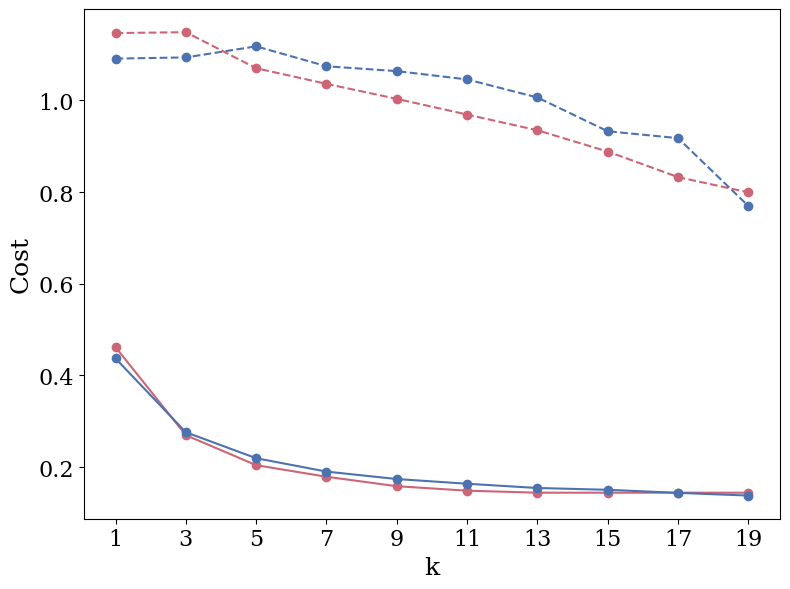

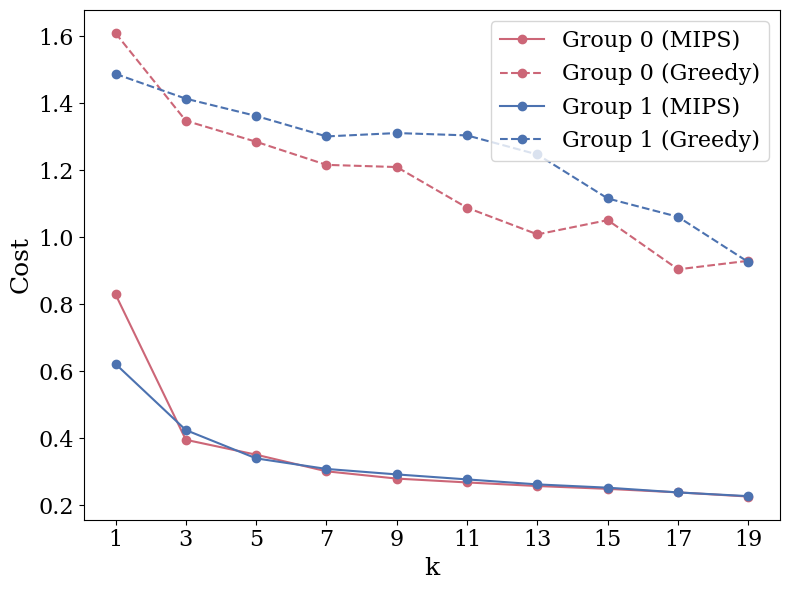

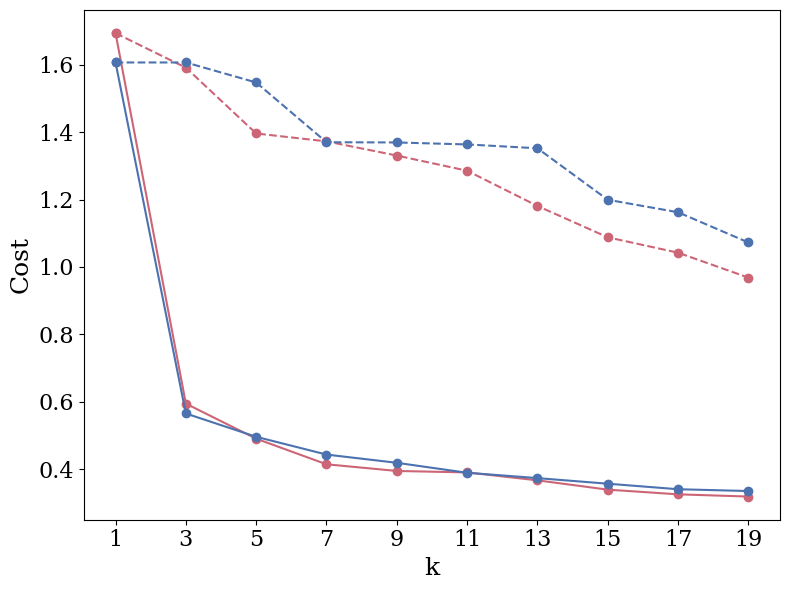

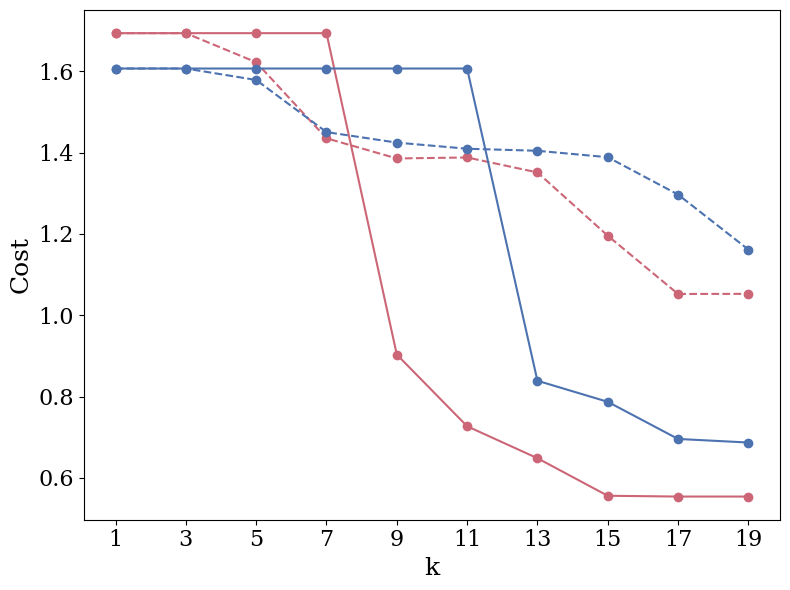

In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt
import os
from metrics import nice_numbers
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16
})

auc_matrix = {}
saturation_points = {}
cost_for_saturation_points = {}
color_group_0 = '#CC6677'
color_group_1 = '#4C72B0'

coverages = [0.25, 0.5, 0.75, 1]
k_values = nice_numbers(1, 20, num_ticks=10, score='k') 
k_values = [int(k) for k in k_values]


for coverage in coverages:
    auc_matrix[coverage] = {}
    saturation_points[coverage] = {}
    cost_for_saturation_points[coverage] = {}

    total_cost_group_0_greedy = []
    total_cost_group_1_greedy = []
    total_cost_group_0_MIPS = []
    total_cost_group_1_MIPS = []

    for k in k_values:
        results_per_group_greedy, max_cost = main_coverage_constrained_GCFEs_Greedy_MIP(epsilon=0.4, datasetName='Adult', 
					group_identifier='sex', classifier="lr", bandwith_approch="mean_scotts_rule", k=k, cost_function = "max_vector_distance",
					group_identifier_value=group_identifier_value, skip_model_training=skip_model_training, skip_distance_calculation=skip_distance_calculation, skip_graph_creation=skip_graph_creation,
					skip_fgce_calculation=skip_fgce_calculation,  skip_bandwith_calculation=skip_bandwith_calculation, cov_constr_approach="global", cov = coverage,  representation=64, fgce_init_dict=None, alg='Greedy')
        results_per_group_MIPS, max_cost = main_coverage_constrained_GCFEs_Greedy_MIP(epsilon=0.4, datasetName='Adult', 
					group_identifier='sex', classifier="lr", bandwith_approch="mean_scotts_rule", k=k, cost_function = "max_vector_distance",
					group_identifier_value=group_identifier_value, skip_model_training=skip_model_training, skip_distance_calculation=skip_distance_calculation, skip_graph_creation=skip_graph_creation,
					skip_fgce_calculation=skip_fgce_calculation,  skip_bandwith_calculation=skip_bandwith_calculation, cov_constr_approach="global", cov = coverage,  representation=64, fgce_init_dict=None, alg='MIPS')

        group_keys = list(results_per_group_greedy.keys())

        total_cost_group_0_greedy.append(results_per_group_greedy[group_keys[0]]["Total Cost"])
        total_cost_group_1_greedy.append(results_per_group_greedy[group_keys[1]]["Total Cost"])

        group_keys = list(results_per_group_MIPS.keys())

        total_cost_group_0_MIPS.append(results_per_group_MIPS[group_keys[0]]["Total Cost"])
        total_cost_group_1_MIPS.append(results_per_group_MIPS[group_keys[1]]["Total Cost"])

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(k_values, total_cost_group_0_MIPS, marker='o', linestyle='-', color=color_group_0, label='Group 0 (MIPS)')
    ax.plot(k_values, total_cost_group_0_greedy, marker='o', linestyle='--', color=color_group_0, label='Group 0 (Greedy)')
    ax.plot(k_values, total_cost_group_1_MIPS, marker='o', linestyle='-', color=color_group_1, label='Group 1 (MIPS)')
    ax.plot(k_values, total_cost_group_1_greedy, marker='o', linestyle='--', color=color_group_1, label='Group 1 (Greedy)')

    ax.set_xlabel("k", fontsize=18)
    ax.set_ylabel("Cost", fontsize=18)

    x_ticks = nice_numbers(1, 20, num_ticks=10, score='k') 
    ax.set_xticks(x_ticks)
    if coverage == 0.5:
        ax.legend(loc="upper right")

    plt.tight_layout()

    filename = f"cost_comparison_greedy_MIPS_cov_{int(coverage * 100)}.pdf"
    plt.savefig(filename, format="pdf", bbox_inches="tight")

    plt.show()
